## Generate Stim circuit

In [7]:
from stimbposd import BPOSD
import matplotlib.pyplot as plt
from sympy.abc import x, y
from qldpc import codes
from qldpc.objects import Pauli
from graph_helper_functions import deform_code_for_logical
import numpy as np
import stim
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)
from deform_triangular_lattice import deform_logical_to_tri_lattice
import numpy as np

import stim
import sinter
import matplotlib.pyplot as plt

### BB code memory performance code-capacity reference

In [11]:
# small BB example BB [[36, 8, 4]]

import qldpc

import numpy as np

BB36_STABILIZERS = """
XIIXIXXIIIIIXIIIIIIIIIXIIIIIIIIIIIII
IXIXXIIXIIIIIXIIIIIIIIIXIIIIIIIIIIII
IIXIXXIIXIIIIIXIIIIIIXIIIIIIIIIIIIII
IIIIIIXIIXIXXIIIIIXIIIIIIIIIXIIIIIII
IIIIIIIXIXXIIXIIIIIXIIIIIIIIIXIIIIII
IIIIIIIIXIXXIIXIIIIIXIIIIIIXIIIIIIII
IIIIIIIIIIIIXIIXIXXIIIIIXIIIIIIIIIXI
IIIIIIIIIIIIIXIXXIIXIIIIIXIIIIIIIIIX
IIIIIIIIIIIIIIXIXXIIXIIIIIXIIIIIIXII
IIIIXIIIIIIIIIIIIIXIIXIXXIIIIIXIIIII
IIIIIXIIIIIIIIIIIIIXIXXIIXIIIIIXIIII
IIIXIIIIIIIIIIIIIIIIXIXXIIXIIIIIXIII
XIIIIIIIIIXIIIIIIIIIIIIIXIIXIXXIIIII
XIIIIIXIIIIIIIIIXIIIIIIIIIIIIIXIIXIX
ZZIZIIIIIIIIIIIIIIIIZIIIIIIZIIIIIZII
IZZIZIIIIIIIIIIIIIZIIIIIIIIIZIIIIIZI
ZIZIIZIIIIIIIIIIIIIZIIIIIIIIIZIIIIIZ
IIIZIIZZIZIIIIIIIIIIIIIIIIZIIIIIIZII
IIIIZIIZZIZIIIIIIIIIIIIIZIIIIIIIIIZI
IIIIIZZIZIIZIIIIIIIIIIIIIZIIIIIIIIIZ
IIIZIIIIIZIIZZIZIIIIIIIIIIIIIIIIZIII
IIIIZIIIIIZIIZZIZIIIIIIIIIIIIIZIIIII
IIIIIZIIIIIZZIZIIZIIIIIIIIIIIIIZIIII
IIZIIIIIIZIIIIIZIIZZIZIIIIIIIIIIIIII
ZIIIIIIIIIZIIIIIZIIZZIZIIIIIIIIIIIII
IZIIIIIIIIIZIIIIIZZIZIIZIIIIIIIIIIII
IIIIIIIIZIIIIIIZIIIIIZIIZZIZIIIIIIII
IIIIIIIIIIIIIIZIIIIIIZIIIIIZIIZZIZII
""".strip().splitlines()

BB36_LOGICALS = """
IIIIIIIIIIXXIIIIIIIIIIXXXXIIIIXXIIII
IIIIIIIIIIIIIIIIIIZIZIIIZIZZZIIIIIII
IIIIIIIIIIIXIIIIIIXXXIIXXXXIIXIXIXXI
IIIIIIIIIIZIIIIIZIIZIIIIIIIZIIIZIZII
IIIIIIIIIIIXIIIIIIIIXIXIIIXIIXIXIXIX
IIIIIIIIIIIZIIIIIZIZIIIIIIIZZZIZIZZZ
IIIIIIIIIIIXIIIIIIIXIXXXIXIIIXIXIIII
IIIIIIIIIIZZIIIIZZZZIIIIIIIIIIZZIIII
IIIIIIIIIIIXIIIIXIIIIIXXIIIIIXXXIIIX
IIIIIIIIIIIIIIIIIIIIIIIIZIZIIIZIZZZI
IIIIIIIIIIIXIIIIIXIIIIIIIIIIIXIIIIIX
IIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIZZZIZ
IIIIIIIIIIIIIIIIIIIIIIIIXIXXXIIIIXXI
IIIIIIIIIIZIIIIIIIIZIIIIIZIZIIIIIIII
IIIIIIIIIIIIIIIIIIIIIIIIIXXXIXIIIXIX
IIIIIIIIIIIZIIIIIIIZIIIIIZIZZZIIIIII
""".strip().splitlines()


def bb36_parse_checks(stabilizer_strings):
    lengths = {len(row) for row in stabilizer_strings}
    if len(lengths) != 1:
        raise ValueError(f"Inconsistent stabilizer string lengths: {sorted(lengths)}")
    x_rows = [row for row in stabilizer_strings if "X" in row]
    z_rows = [row for row in stabilizer_strings if "Z" in row]
    Hx = np.array([[c == "X" for c in row] for row in x_rows], dtype=np.uint8)
    Hz = np.array([[c == "Z" for c in row] for row in z_rows], dtype=np.uint8)
    return Hx, Hz


def bb36_parse_logicals(logical_strings):
    lengths = {len(row) for row in logical_strings}
    if len(lengths) != 1:
        raise ValueError(f"Inconsistent logical string lengths: {sorted(lengths)}")
    if len(logical_strings) % 2:
        raise ValueError("Expected alternating X/Z logical rows")
    logical_X = np.array([[c == "X" for c in row] for row in logical_strings[0::2]], dtype=np.uint8)
    logical_Z = np.array([[c == "Z" for c in row] for row in logical_strings[1::2]], dtype=np.uint8)
    return logical_X, logical_Z



Hx, Hz = bb36_parse_checks(BB36_STABILIZERS)
logical_X, logical_Z = bb36_parse_logicals(BB36_LOGICALS)
H = np.vstack([
    np.hstack([Hx, np.zeros((Hx.shape[0], Hz.shape[1]), dtype=np.uint8)]),
    np.hstack([np.zeros((Hz.shape[0], Hx.shape[1]), dtype=np.uint8), Hz]),
])


class BB36Code:
    def __init__(self):
        self.label = "BB [[36,8,4]]"
        self.Hx = Hx
        self.Hz = Hz
        self.logical_X = logical_X
        self.logical_Z = logical_Z
        self.matrix = H.astype(np.uint8)

    def get_logical_ops(self, basis):
        if basis == Pauli.X or str(basis).upper().endswith("X"):
            return self.logical_X
        if basis == Pauli.Z or str(basis).upper().endswith("Z"):
            return self.logical_Z
        raise ValueError(f"Unknown basis: {basis}")


class BB144Code:


    def __init__(self):
        self.label = "BB [[144,12,12]]"
        self.Hx = Hx
        self.Hz = Hz
        self.logical_X = logical_X
        self.logical_Z = logical_Z
        self.matrix = H.astype(np.uint8)

    def get_logical_ops(self, basis):
        if basis == Pauli.X or str(basis).upper().endswith("X"):
            return self.logical_X
        if basis == Pauli.Z or str(basis).upper().endswith("Z"):
            return self.logical_Z
        raise ValueError(f"Unknown basis: {basis}")


a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 12, y: 6}


def BB144Code():
    return codes.BBCode(orders=orders, poly_a=a, poly_b=b)

BB36 = BB36Code()
BB144 = BB144Code()


# def get_BB_98_6_12():
#     return codes.BBCode(
#         orders={x: 7, y: 7},
#         poly_a=x**3 + y**3 + y**4,
#         poly_b=y**6 + x**2 + x**5,
#     )

# def get_BB_72_12_6():
#     return codes.BBCode(
#         orders={x: 6, y: 6},
#         poly_a=x**3 + y + y**2,
#         poly_b=y**3 + x + x**2,
#     )


In [ ]:
BB_code = BB36Code()
ps = np.logspace(-5, -1, 3)
shots = 1000
rounds=4
logical_indices = range(8)

In [13]:
from bb_memory_sweeps import bb_run_memory_sweep

def bb_plot_memory_sweep(result, ax=None):
    ps = result["ps"]
    raw = result["raw"]
    decoded = result["decoded"]
    basis = result["basis"]
    logical_indices = result["logical_indices"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.8))
    else:
        fig = ax.figure

    colors = [
        "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#4c78a8", "#54a24b", "#b279a2", "#72b7b2",
    ]
    for i, logical_i in enumerate(logical_indices):
        color = colors[i % len(colors)]
        ax.loglog(ps, raw[i], "--", color=color, alpha=0.22, linewidth=0.9)
        ax.loglog(ps, decoded[i], "o-", color=color, alpha=0.75, linewidth=1.1, markersize=3, label=f"{basis}{logical_i}")

    avg_decoded_memory = np.mean(decoded, axis=0)
    ax.loglog(ps, np.mean(raw, axis=0), "k--", linewidth=3.0, label=f"avg undecoded {basis}")
    ax.loglog(ps, avg_decoded_memory, "k-", linewidth=3.0, label=f"avg decoded {basis}")
    ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")
    ax.set_title(f"{result.get('code_label', 'BB code')} {basis}-memory, {result['rounds']} rounds")
    ax.set_xlabel("physical error probability p")
    ax.set_ylabel("logical memory error probability")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()
    return fig, ax, avg_decoded_memory

bb_memory_results = {}
for bb_memory_basis in [Pauli.Z, Pauli.X]:
    res = bb_run_memory_sweep(
        BB_code=BB_code,
        memory_basis=bb_memory_basis,
        ps=ps,
        rounds=rounds,
        shots=shots,
        noise_model="circuit-level"
    )
    bb_memory_results[res["basis"]] = res
    if bb_memory_basis == Pauli.Z:
        fig, ax, avg_decoded_memory_z = bb_plot_memory_sweep(res)
    else:
        fig, ax, avg_decoded_memory_x = bb_plot_memory_sweep(res)
    


logical 0: detectors=126, observables=1, L0 terms=1595
logical 1: detectors=126, observables=1, L0 terms=750
logical 2: detectors=126, observables=1, L0 terms=1820
logical 3: detectors=126, observables=1, L0 terms=1159
logical 4: detectors=126, observables=1, L0 terms=1283
logical 5: detectors=126, observables=1, L0 terms=825
logical 6: detectors=126, observables=1, L0 terms=577
logical 7: detectors=126, observables=1, L0 terms=1377
BB memory Z, p=1.00e-04, avg raw=0.00875, avg decoded=0
logical 0: detectors=126, observables=1, L0 terms=1595
logical 1: detectors=126, observables=1, L0 terms=750
logical 2: detectors=126, observables=1, L0 terms=1820
logical 3: detectors=126, observables=1, L0 terms=1159
logical 4: detectors=126, observables=1, L0 terms=1283
logical 5: detectors=126, observables=1, L0 terms=825
logical 6: detectors=126, observables=1, L0 terms=577
logical 7: detectors=126, observables=1, L0 terms=1377
BB memory Z, p=3.16e-03, avg raw=0.2331, avg decoded=0.01488
logical 0

KeyboardInterrupt: 

## BB [36 8 4] with gadget

In [3]:
stim.Circuit.generated(code_task="surface_code:rotated_memory_x", distance=3, rounds=6, after_clifford_depolarization=0.1, before_measure_flip_probability=0.1, after_reset_flip_probability=0.1, before_round_data_depolarization=0.1)
#circuit.without_noise().diagram("detslice-with-ops-svg")

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    RX 1 3 5 8 10 12 15 17 19
    Z_ERROR(0.1) 1 3 5 8 10 12 15 17 19
    R 2 9 11 13 14 16 18 25
    X_ERROR(0.1) 2 9 11 13 14 16 18 25
    TICK
    DEPOLARIZE1(0.1) 1 3 5 8 10 12 15 17 19
    H 2 11 16 25
    DEPOLARIZE1(0.1) 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    DEPOLARIZE2(0.1) 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    DEPOLARIZE2(0.1) 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    DEPOLARIZE2(0.1) 16 10 11 5 25 19 8 9 17 18 12 13
   

In [15]:
# Code-capacity logical measurement gadget experiment
import bb_gadget_sweeps
from bb_gadget_sweeps import get_deformed_logical, estimate_logical_measurement_error_rate

logical_measurement_deformations = {}

logical_measurement_results = {}

for logical_basis, basis_name in [(Pauli.Z, 'Z'), (Pauli.X, 'X')]:
    
    raw = np.zeros((len(logical_indices), len(ps)))
    decoded = np.zeros_like(raw)

    for i, logical_i in enumerate(logical_indices):
        def_res = get_deformed_logical(BB_code, logical_basis, logical_i)
        for j, p in enumerate(ps):
            raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
                BB_code=BB_code,
                def_res=def_res,
                logical_basis=logical_basis,
                logical_index=logical_i,
                p=float(p),
                rounds=rounds,
                shots=shots,
                noise_model = "circuit-level",
                noise_target="both"
            )
            print(
                f'{basis_name}{logical_i:02d}, p={p:.2e}, '
                f'raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}'
            )

    logical_measurement_results[basis_name] = {
        'ps': ps.copy(),
        'raw': raw,
        'decoded': decoded,
    }

    fig, ax = plt.subplots(figsize=(7, 4.8))


    for i, logical_i in enumerate(logical_indices):
        ax.loglog(ps, raw[i], '--', alpha=0.22, linewidth=0.9)
        ax.loglog(
            ps,
            decoded[i],
            '-',
            alpha=0.75,
            linewidth=1.2,
            markersize=3,
            label=f'{basis_name}{logical_i}'
        )

    avg_raw = np.mean(raw, axis=0)
    if logical_basis == Pauli.Z:
        avg_decoded_gadget_z = np.mean(decoded, axis=0)
    else:
        avg_decoded_gadget_x = np.mean(decoded, axis=0)
    avg_decoded_gadget = np.mean(decoded, axis=0)
    ax.loglog(ps, avg_raw, 'k--', linewidth=3.0, label=f'avg undecoded {basis_name}')
    ax.loglog(ps, avg_decoded_gadget, 'k-', linewidth=3.0, label=f'avg decoded {basis_name}')

    # pseudo-threshold reference line: logical error = physical error
    ax.loglog(ps, ps, '--', color='red', linewidth=2.2, label=r'$p_L = p$')

    ax.set_title(f'{basis_name}-logical measurement gadget, {rounds} rounds')
    ax.set_xlabel('physical error probability p')
    ax.set_ylabel('logical measurement error probability')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()




Z00, p=1.00e-04, raw=0.004, decoded=0.005
Z00, p=3.16e-03, raw=0.258, decoded=0.086


KeyboardInterrupt: 

# Direct measurement vs. graph measurment

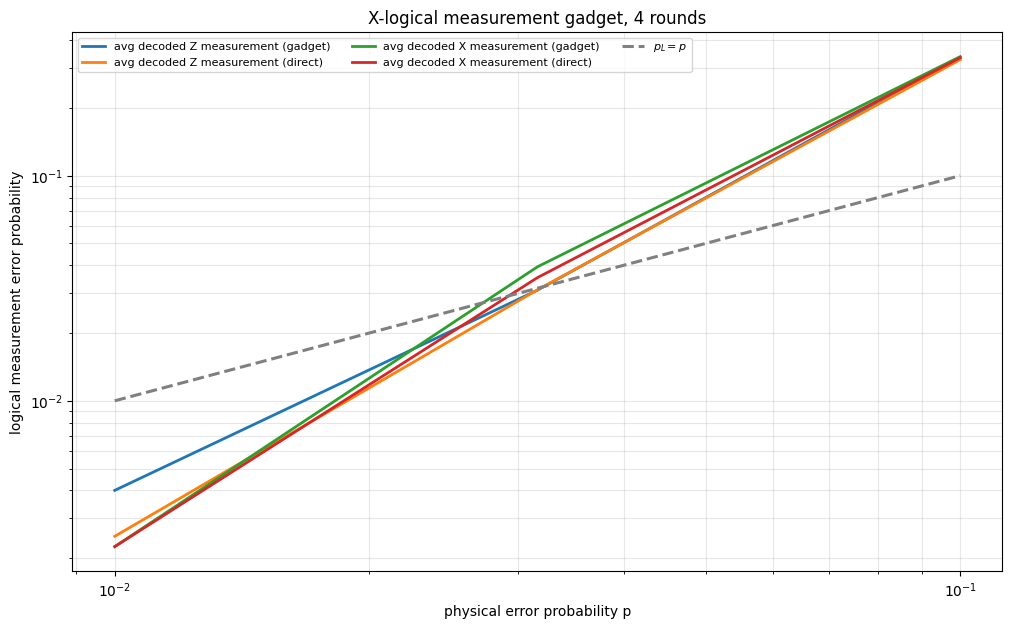

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))


ax.loglog(ps, avg_decoded_gadget_z, '-', linewidth=2.0, label=f'avg decoded Z measurement (gadget)')
ax.loglog(ps, avg_decoded_memory_z, "-", linewidth=2.0, label =f"avg decoded Z measurement (direct)")
ax.loglog(ps, avg_decoded_gadget_x, '-', linewidth=2.0, label=f'avg decoded X measurement (gadget)')
ax.loglog(ps, avg_decoded_memory_x, "-", linewidth=2.0, label =f"avg decoded X measurement (direct)")

# pseudo-threshold reference line: logical error = physical error
ax.loglog(ps, ps, '--', color='grey', linewidth=2.2, label=r'$p_L = p$')

ax.set_title(f'{basis_name}-logical measurement gadget, {rounds} rounds')
ax.set_xlabel('physical error probability p')
ax.set_ylabel('logical measurement error probability')
ax.grid(True, which='both', alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.show()


## Shuttling vs. planarity

In [25]:
shuttling_thresholds = [0, 1, 2, 3, 30]
ps = np.logspace(-6, -2, 3)
logical_basis = Pauli.Z
basis_name = "Z"
logical_i = 0
shots = 1000
rounds = 4
raw = np.zeros((len(shuttling_thresholds), len(ps)))
decoded = np.zeros_like(raw)
n_shuttles = []

for i, thresh in enumerate(shuttling_thresholds):
    deformation = get_deformed_logical(
        BB_code,
        logical_basis=logical_basis,
        logical_index=logical_i,
        shuttling_threshold=thresh,
    )
    n_shuttles.append(deformation["n_shuttling_edges"])

    for j, p in enumerate(ps):
        raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
            BB_code=BB_code,
            def_res=deformation,
            logical_basis=logical_basis,
            logical_index=logical_i,
            p=float(p),
            rounds=rounds,
            shots=shots,
            noise_model="circuit-level",
        )
        print(
            f"{basis_name}{logical_i:02d}, threshold={thresh}, "
            f"shuttles={n_shuttles[-1]}, p={p:.2e}, "
            f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
        )

shuttling_sweep_results = {
    "ps": ps.copy(),
    "thresholds": np.asarray(shuttling_thresholds),
    "n_shuttles": np.asarray(n_shuttles),
    "raw": raw,
    "decoded": decoded,
}



Z00, threshold=0, shuttles=12, p=1.00e-06, raw=0, decoded=0
Z00, threshold=0, shuttles=12, p=1.00e-04, raw=0.012, decoded=0.015


KeyboardInterrupt: 

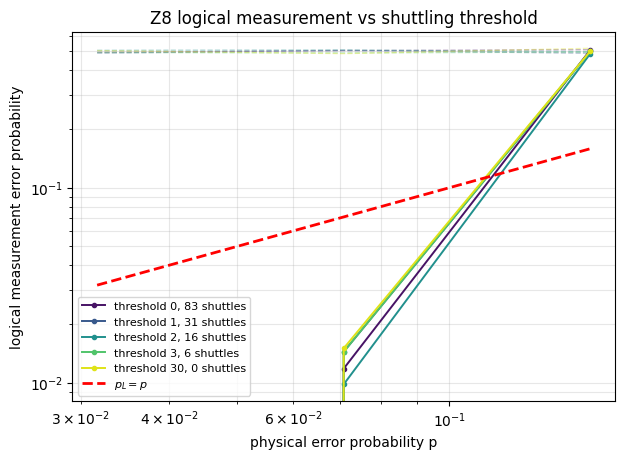

In [85]:
fig, ax = plt.subplots(figsize=(7, 4.8))

colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(shuttling_thresholds)))

for i, thresh in enumerate(shuttling_thresholds):
    label = f"threshold {thresh}, {n_shuttles[i]} shuttles"
    ax.loglog(ps, raw[i], "--", color=colors[i], alpha=0.35, linewidth=1.0)
    ax.loglog(ps, decoded[i], "o-", color=colors[i], linewidth=1.4, markersize=3, label=label)

ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")

ax.set_title(f"{basis_name}{logical_i} logical measurement vs shuttling threshold")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

## Heterogenous noise

In [90]:
ps = np.logspace(-1.5, -0.8, 3)
logical_basis = Pauli.Z
basis_name = "Z"
logical_i = 8
shots = 5000
rounds = 6
raw = np.zeros((3, len(ps)))
decoded = np.zeros_like(raw)
noise_models = ["gadget", "data", "both"]

for i in range(3):
    deformation = get_deformed_logical(
        BB_code,
        logical_basis=logical_basis,
        logical_index=logical_i,
        shuttling_threshold=2,
    )

    for j, p in enumerate(ps):
        raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
            BB_code=BB_code,
            def_res=deformation,
            logical_basis=logical_basis,
            logical_index=logical_i,
            p=float(p),
            rounds=rounds,
            shots=shots,
            noise_model = noise_models[i]

        )
        print(
            f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
        )

heterogenous_noise_results = {
    "ps": ps.copy(),
    "noise_models":  noise_models,
    "raw": raw,
    "decoded": decoded,
}

detectors: 1151
observables: 1
L0 terms: 288
raw=0.5, decoded=0
detectors: 1151
observables: 1
L0 terms: 288
raw=0.512, decoded=0.0128
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5008, decoded=0.4908
detectors: 1151
observables: 1
L0 terms: 288
raw=0.4974, decoded=0.0004
detectors: 1151
observables: 1
L0 terms: 288
raw=0.512, decoded=0.014
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5106, decoded=0.4972
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5026, decoded=0
detectors: 1151
observables: 1
L0 terms: 288
raw=0.4994, decoded=0.015
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5112, decoded=0.5012


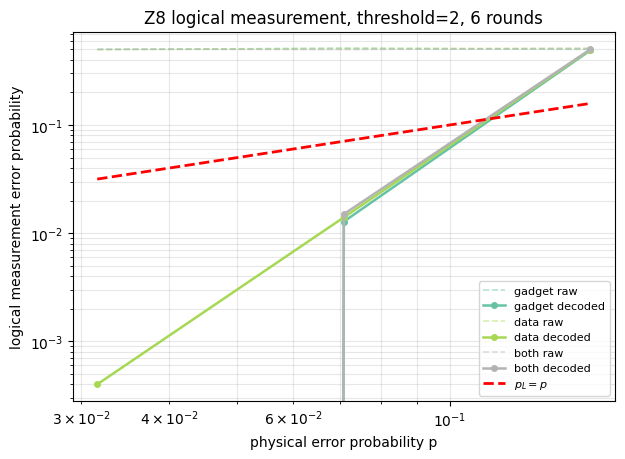

In [91]:
res = heterogenous_noise_results

ps = res["ps"]
noise_models = res["noise_models"]
raw = res["raw"]
decoded = res["decoded"]

fig, ax = plt.subplots(figsize=(7, 4.8))
colors = plt.cm.Set2(np.linspace(0, 1, len(noise_models)))

for i, noise_model in enumerate(noise_models):
    ax.loglog(
        ps,
        raw[i],
        "--",
        color=colors[i],
        alpha=0.45,
        linewidth=1.2,
        label=f"{noise_model} raw",
    )
    ax.loglog(
        ps,
        decoded[i],
        "o-",
        color=colors[i],
        linewidth=1.8,
        markersize=4,
        label=f"{noise_model} decoded",
    )

ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")

ax.set_title(f"{basis_name}{logical_i} logical measurement, threshold=2, {rounds} rounds")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()